# PDAN8411 – PART 2: CLASSIFICATION AND MODEL IMPROVEMENT

## Student Details
- Ubaid Omarjee
- ST10315716

## Project Overview
This project develops a machine learning classification model to assist a South African medical aid scheme in identifying cancer cases efficiently. The notebook includes dataset justification, exploratory data analysis, feature selection, model training, evaluation, model improvement and business-focused interpretation.

In [1]:

# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

# Dataset Justification

The Breast Cancer Wisconsin dataset was selected for this classification project because it is highly suitable for supervised machine learning classification tasks. The dataset contains numerical medical measurements collected from breast cancer patients and includes a target variable indicating whether the tumour is malignant or benign.

The dataset is appropriate because:
- It contains high-quality structured numerical data
- It has sufficient features for advanced analysis
- It supports binary classification
- It is commonly used in healthcare machine learning research
- It allows the application of multiple classification algorithms

Potential limitations include:
- The dataset is relatively small
- It may not fully represent all population groups
- Real-world medical datasets are often more complex

In [2]:

# LOAD DATASET

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Exploratory Data Analysis (EDA)

The purpose of EDA is to understand the structure, quality and characteristics of the dataset before model training.

In [3]:
# Dataset Shape

df.shape

(569, 31)

The dataset dimensions show the number of observations and variables available for training. A sufficient number of observations helps improve model reliability and generalisation.

In [4]:
# Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

All variables are numerical, which is advantageous for machine learning algorithms because minimal encoding is required. The target variable is binary, making the dataset suitable for classification.

In [5]:
# Missing Values

df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


No missing values were identified in the dataset. This improves data quality and reduces the need for imputation techniques.

In [6]:
# Duplicate Records

df.duplicated().sum()

np.int64(0)

Duplicate records were checked to ensure data integrity and prevent biased model learning.

In [7]:
# Statistical Summary

df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


The statistical summary provides insight into feature distributions, variation, minimum and maximum values and potential outliers. Some variables show large ranges, suggesting that scaling may improve model performance.

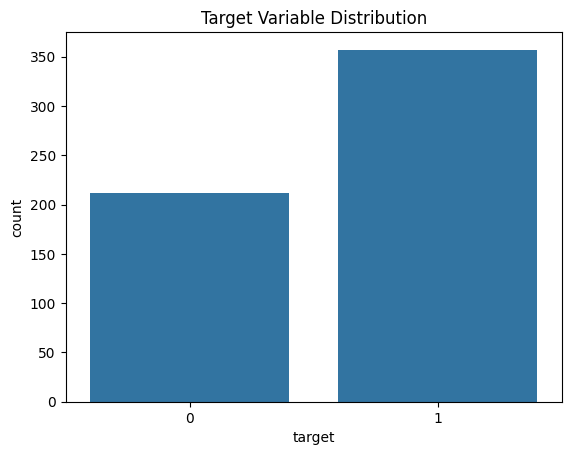

In [8]:
# Class Distribution

sns.countplot(x='target', data=df)

plt.title("Target Variable Distribution")

plt.show()

The class distribution helps determine whether the dataset is balanced or imbalanced. Severe imbalance may negatively affect classification performance.

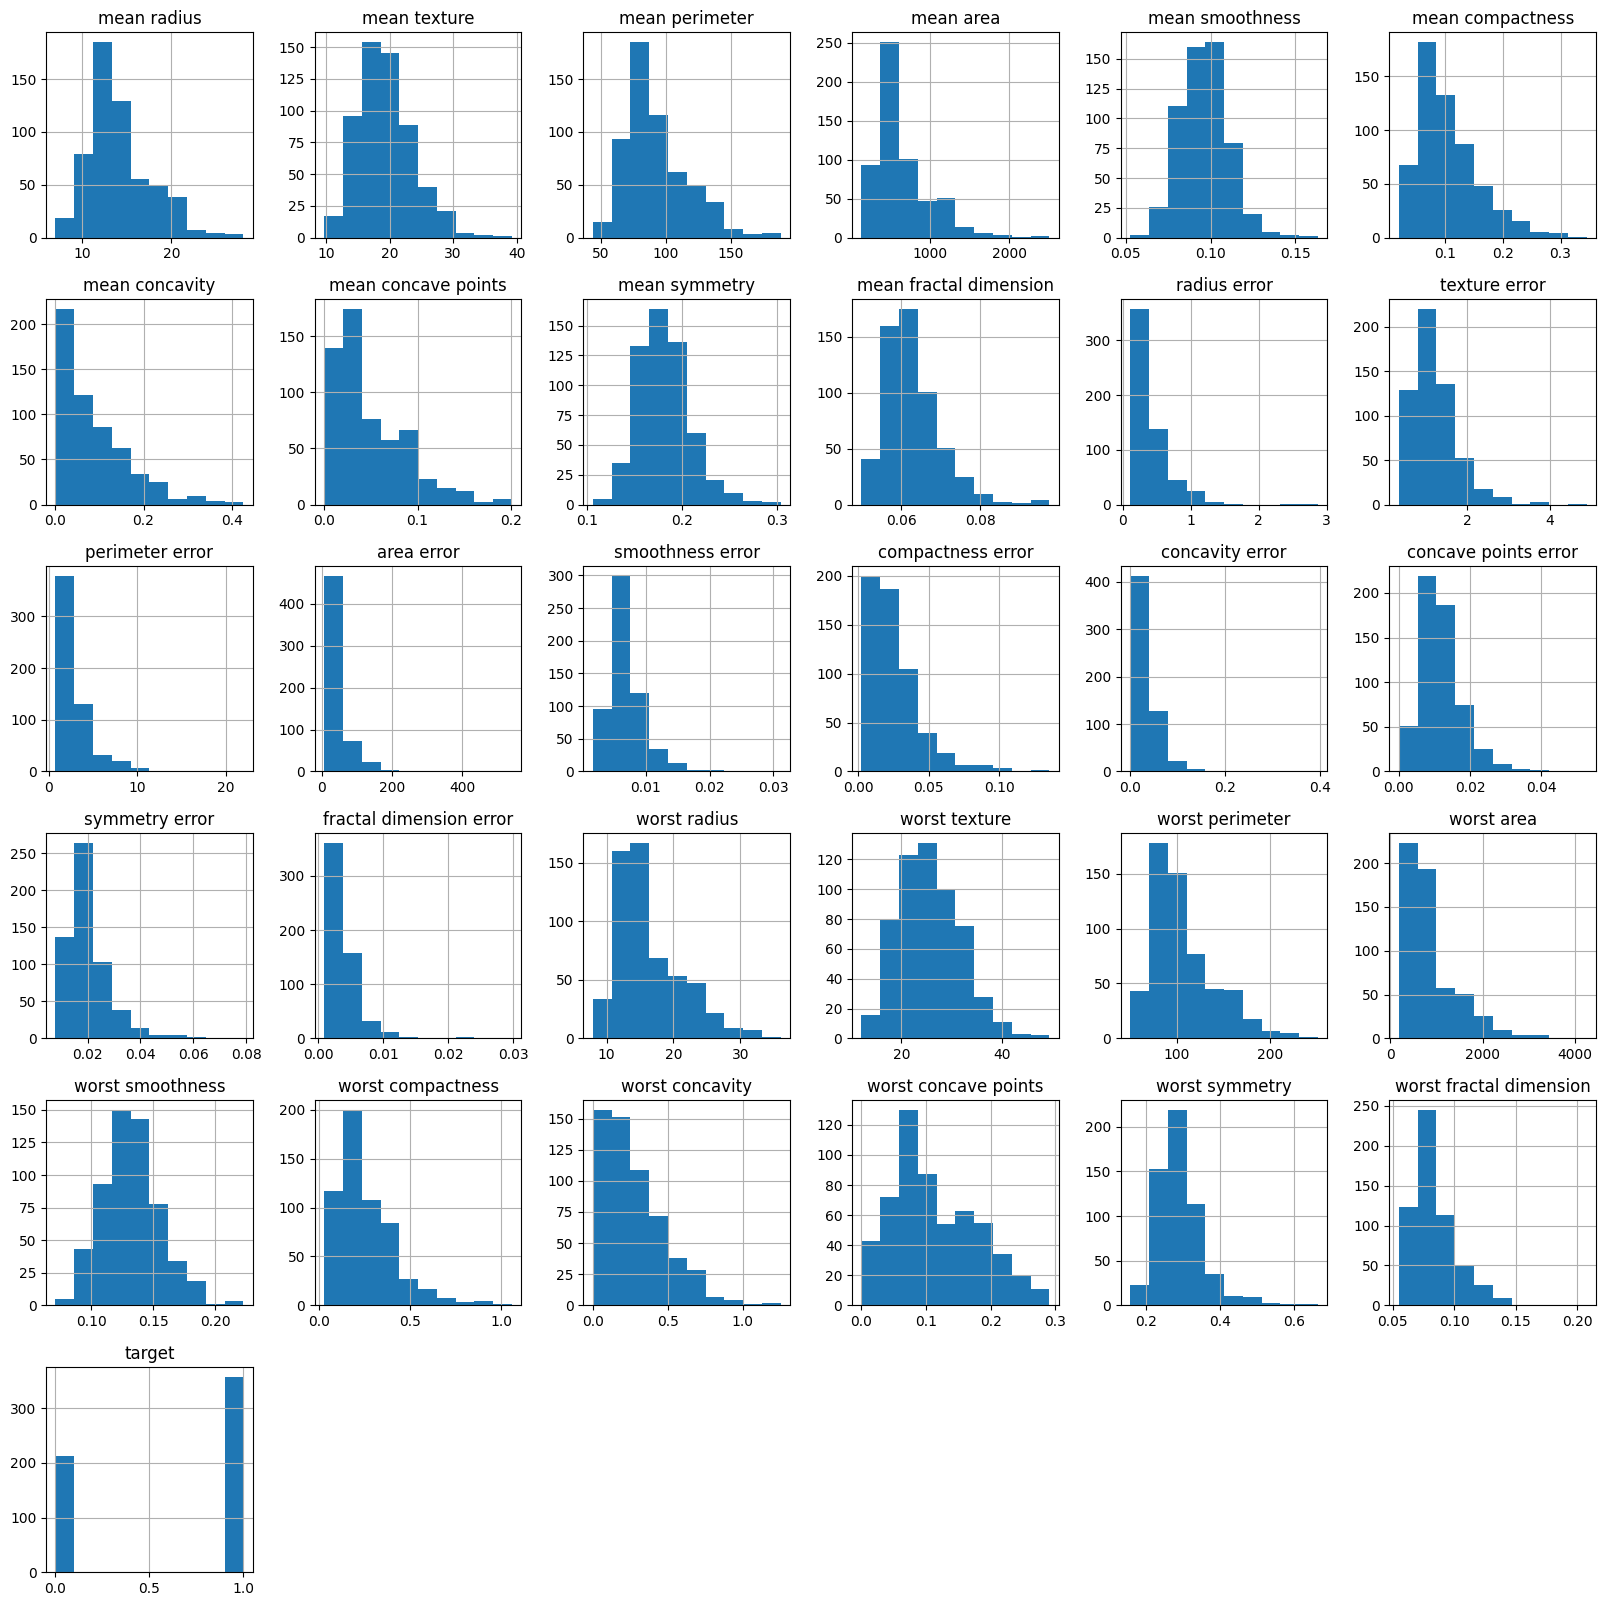

In [9]:
# Histograms

df.hist(figsize=(20,20))

plt.show()

The histograms show the distributions of the numerical variables. Several features appear skewed, indicating that scaling and preprocessing may improve model performance.

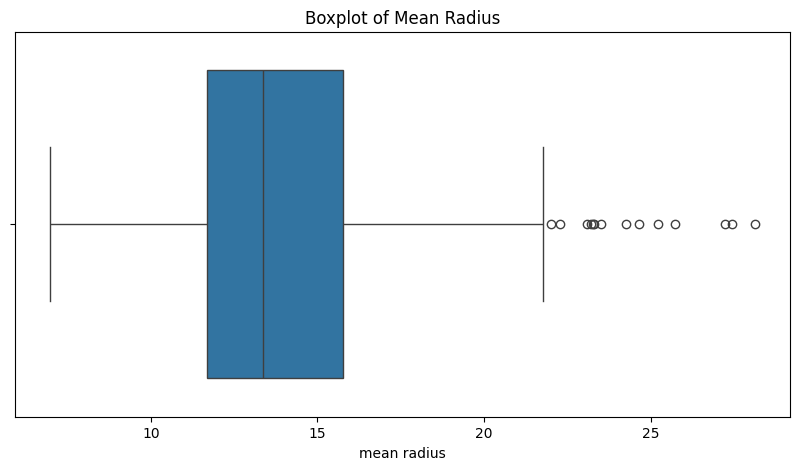

In [10]:
# Boxplot

plt.figure(figsize=(10,5))

sns.boxplot(x=df['mean radius'])

plt.title("Boxplot of Mean Radius")

plt.show()

The boxplot helps identify outliers and extreme values. Outliers may influence classification boundaries and model stability.

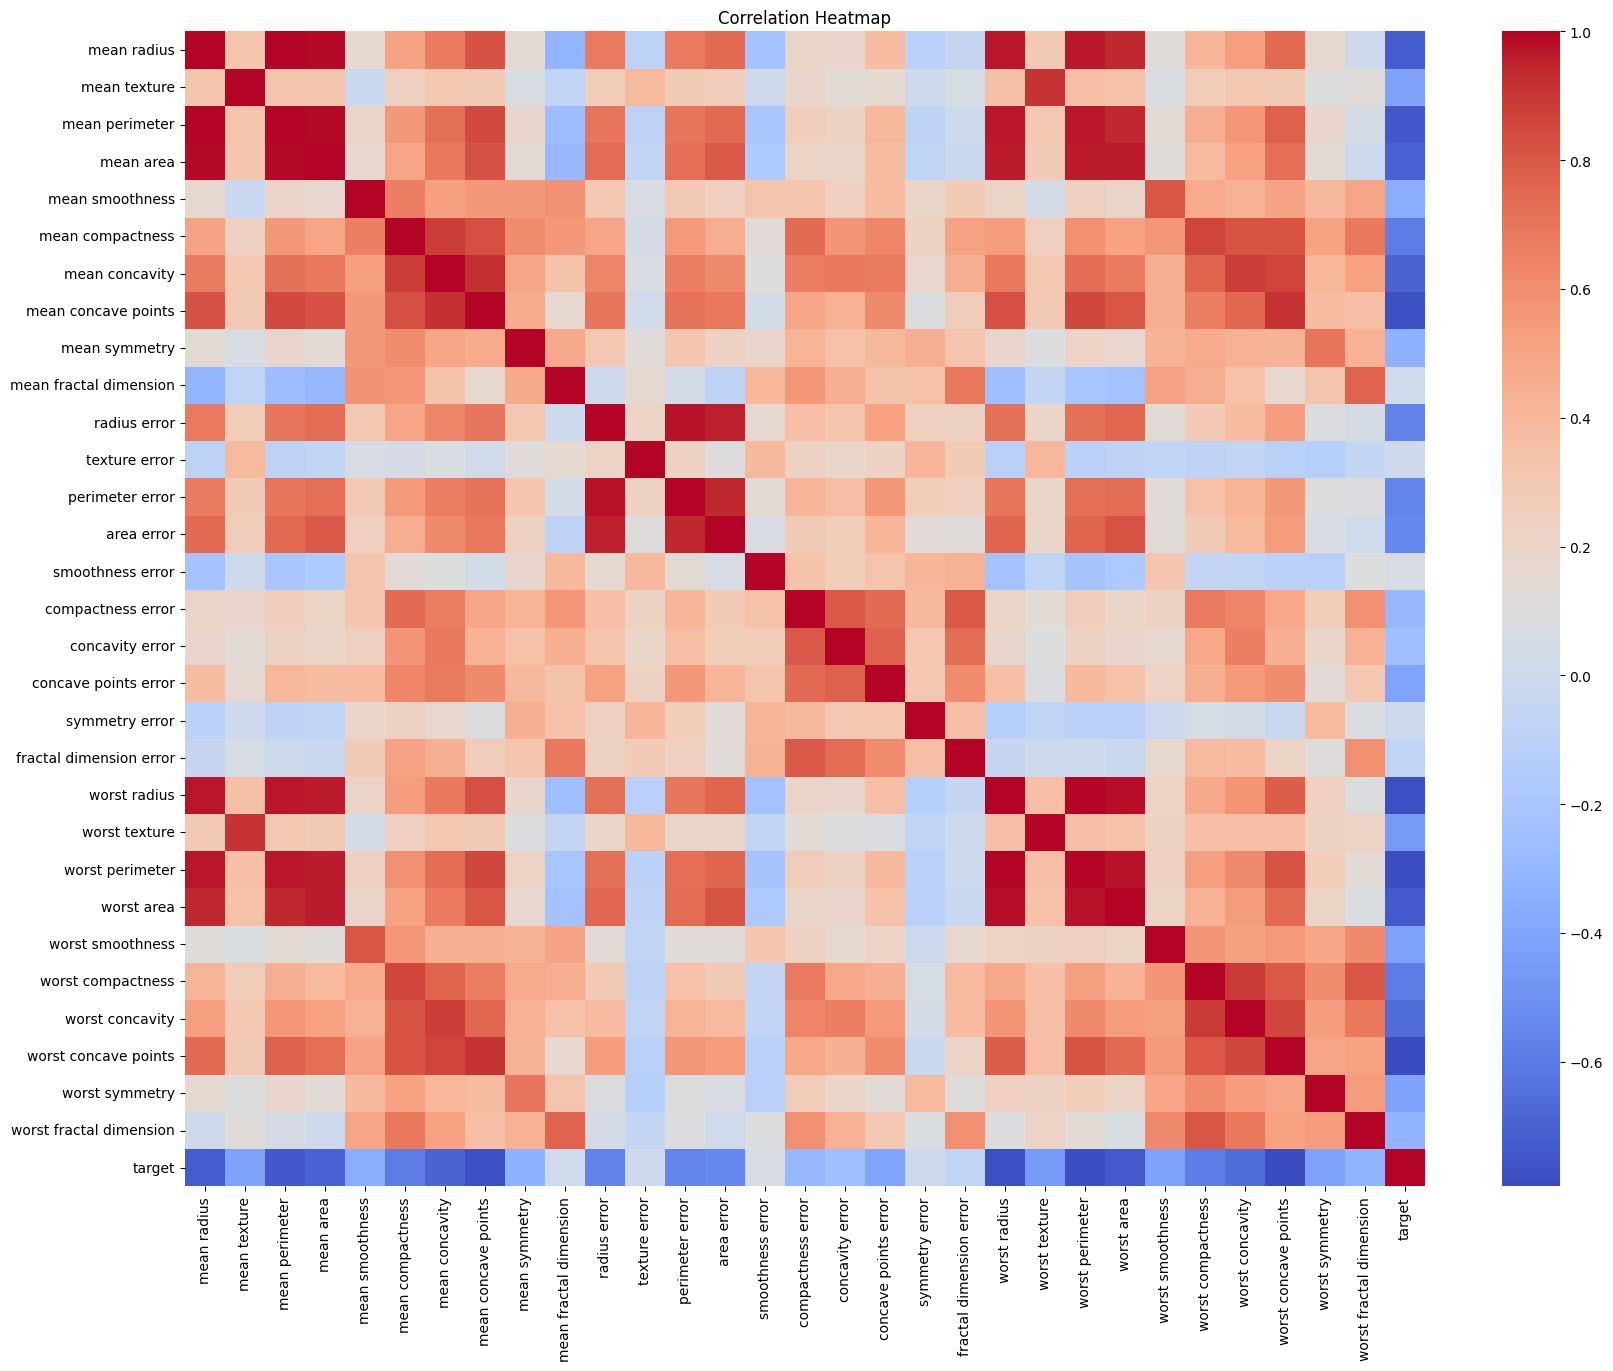

In [11]:
# Correlation Heatmap

plt.figure(figsize=(20,15))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

The heatmap identifies relationships between variables. Strong correlations may indicate multicollinearity, which can negatively impact certain machine learning models.

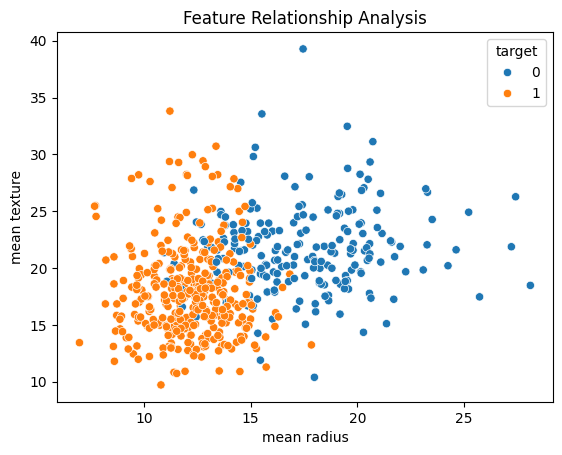

In [12]:
# Scatterplot

sns.scatterplot(
    x='mean radius',
    y='mean texture',
    hue='target',
    data=df
)

plt.title("Feature Relationship Analysis")

plt.show()

The scatterplot shows how the selected features separate the target classes. Good separation indicates that the features may be useful for classification.

In [13]:
# VIF Analysis

X_vif = df.drop('target', axis=1)

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(len(X_vif.columns))
]

vif_data

,Feature,VIF
0,mean radius,63306.172036
1,mean texture,251.047108
2,mean perimeter,58123.586079
3,mean area,1287.262339
4,mean smoothness,393.398166
5,mean compactness,200.980354
6,mean concavity,157.855046
7,mean concave points,154.241268
8,mean symmetry,184.426558
9,mean fractal dimension,629.679874


Variance Inflation Factor (VIF) analysis was conducted to identify multicollinearity between variables. High VIF scores suggest strong correlations between predictors, which may affect model interpretability.

In [14]:
# Feature Selection

X = df.drop('target', axis=1)

y = df['target']

Feature selection was performed by separating predictor variables from the target variable. The selected variables contain important medical measurements relevant to cancer classification.

In [15]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


The dataset was divided into training and testing sets to evaluate the model on unseen data. Stratification was applied to preserve class distribution.

In [16]:
# Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

A preprocessing pipeline was implemented to automate scaling and model training. Pipelines improve workflow efficiency and reduce data leakage risk.

In [17]:
# Train Logistic Regression

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [18]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9824561403508771


In [19]:
# Other Metrics

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112


Recall is particularly important in medical classification because failing to detect cancer cases may have severe consequences.

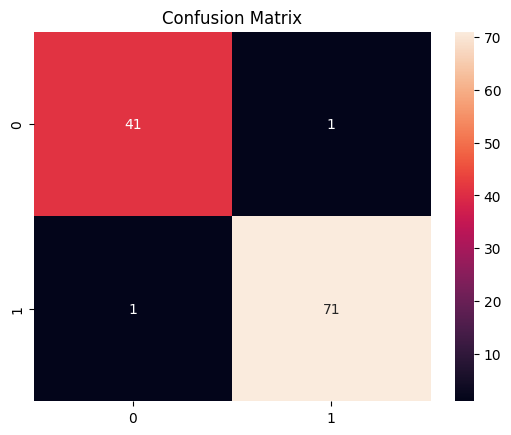

In [20]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

The confusion matrix identifies correct and incorrect predictions. False negatives are especially critical in healthcare environments.

In [21]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



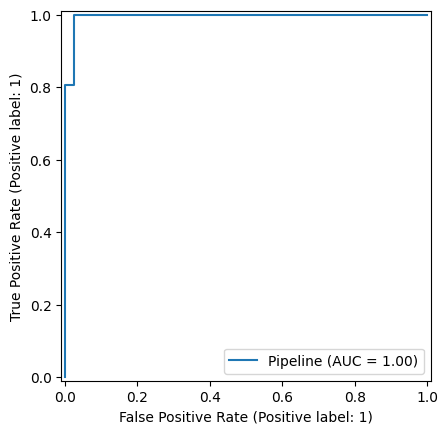

In [22]:
# ROC Curve

RocCurveDisplay.from_estimator(
    pipeline,
    X_test,
    y_test
)

plt.show()

The ROC curve evaluates the model’s ability to distinguish between classes across multiple thresholds.

In [23]:
# Cross Validation

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5
)

print(scores)

print("Average CV Score:", scores.mean())

[0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]
Average CV Score: 0.9806862288464524


Cross-validation improves evaluation reliability by testing the model across multiple dataset splits.

In [24]:
# Random Forest

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [25]:
# Random Forest Accuracy

print("RF Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

RF Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



The Random Forest model was trained to compare performance against Logistic Regression. Ensemble methods often improve classification accuracy and robustness.

In [26]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


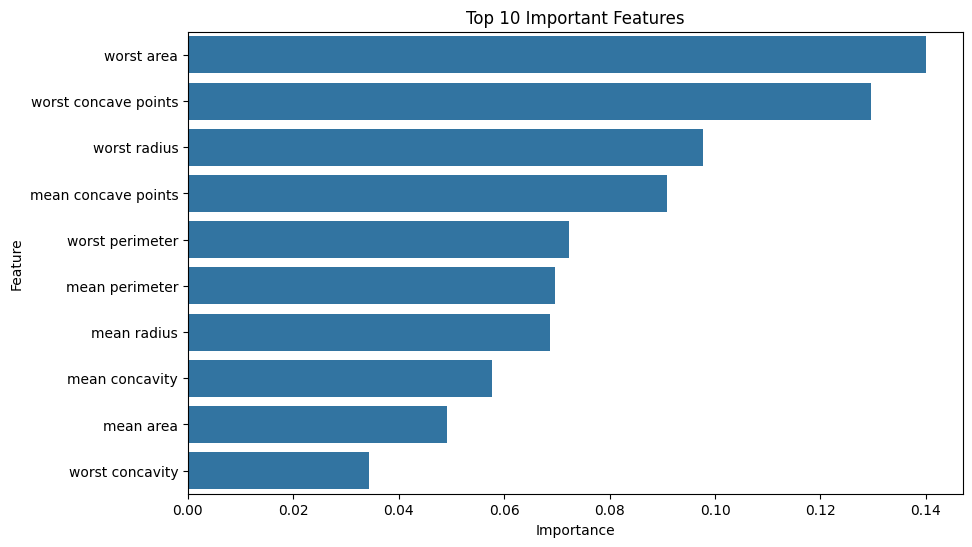

In [27]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

Feature importance analysis identifies the medical measurements that contribute most strongly to cancer classification.

In [28]:
# Hyperparameter Tuning

params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 50}


GridSearchCV was used to optimise hyperparameters and improve model performance.

In [29]:
# Improved Model

best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# Business Interpretation

The classification model demonstrates strong potential for assisting medical aid schemes with faster cancer risk assessment and benefit approval processes.

The model may help:
- Improve early detection support
- Prioritise high-risk patients
- Reduce manual review workloads
- Improve operational efficiency

However, false negatives remain a significant concern because missed cancer cases may delay treatment.

# Limitations

Several limitations were identified:
- The dataset is relatively small
- Real-world medical data may contain more noise
- Ethical concerns exist regarding automated medical decisions
- The dataset may not represent all demographic groups

# Future Improvements

Future improvements may include:
- Larger datasets
- Deep learning models
- Real-time clinical integration
- Additional patient variables
- External validation datasets

# References

Kaggle. (2025). Breast Cancer Wisconsin Dataset. Available at:
https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

Scikit-learn. (2025). Machine Learning in Python. Available at:
https://scikit-learn.org/


Seaborn Documentation. (2025). Statistical Data Visualization. Available at:
https://seaborn.pydata.org/

Pandas Documentation. (2025). Python Data Analysis Library. Available at:
https://pandas.pydata.org/